# NB_05 — Construcción del dataset supervisado de meta-labeling


Este notebook inicia el bloque de Inteligencia Artificial del TFM. La decisión metodológica es congelar el screener técnico V4 y utilizarlo como **generador de eventos candidatos**. Cada señal técnica candidata se convierte en una fila de un dataset supervisado.

La pregunta de modelado será:

> Dada una señal técnica candidata generada por el screener V4, ¿puede un modelo supervisado estimar si esa señal terminará siendo positiva bajo la lógica de gestión definida?

Esta versión trabaja sin FinBERT. El objetivo es construir primero un dataset técnico-supervisado limpio, auditable y sin leakage.


## 0. Carga de Archivos
- `df_nb04b2_v4_signal_trade_audit.csv`
- `df_nb04b_v4_daily_audit.csv.zip`

El primer archivo contiene las señales V4 y su resultado posterior. El segundo contiene el panel diario completo de indicadores y estados técnicos obtenidos en los pasos anteriores


In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

BASE = Path.cwd()
OUTPUT_DIR = BASE / "outputs_nb05"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Carpeta de trabajo:", BASE)
print("Carpeta de salida:", OUTPUT_DIR)


Carpeta de trabajo: /Users/rbr/TFM_MVP/JUNIO
Carpeta de salida: /Users/rbr/TFM_MVP/JUNIO/outputs_nb05


In [2]:
def find_required_file(filename: str) -> Path:
    """Busca un archivo en la carpeta actual y subcarpetas típicas."""
    candidates = [
        BASE / filename,
        BASE / "data" / filename,
        BASE / "inputs" / filename,
        BASE / "outputs" / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = list(BASE.rglob(filename))
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"No se encontró {filename}. Colócalo junto al notebook o en una carpeta data/."
    )

SIGNALS_PATH = find_required_file("df_nb04b2_v4_signal_trade_audit.csv")
DAILY_ZIP_PATH = find_required_file("df_nb04b_v4_daily_audit.csv.zip")

print("Señales:", SIGNALS_PATH)
print("Dataset diario:", DAILY_ZIP_PATH)


Señales: /Users/rbr/TFM_MVP/JUNIO/df_nb04b2_v4_signal_trade_audit.csv
Dataset diario: /Users/rbr/TFM_MVP/JUNIO/df_nb04b_v4_daily_audit.csv.zip


## 1. Carga de señales V4

La unidad de análisis del dataset supervisado será una señal técnica candidata. Por eso empezamos desde `df_nb04b2_v4_signal_trade_audit.csv`.

Estas señales ya contienen el resultado posterior de la operación. Ese resultado se usará para construir la etiqueta supervisada, pero no podrá usarse como feature predictora.


In [3]:
signals = pd.read_csv(SIGNALS_PATH)

signals["signal_date"] = pd.to_datetime(signals["signal_date"])
signals["entry_date"] = pd.to_datetime(signals["entry_date"])

print("Dimensión signals:", signals.shape)
print("Fechas:", signals["signal_date"].min(), "→", signals["signal_date"].max())
print("Tickers:", signals["Ticker"].nunique())
display(signals.head())


Dimensión signals: (8155, 38)
Fechas: 2018-04-16 00:00:00 → 2025-12-22 00:00:00
Tickers: 502


,signal_id,Ticker,Year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,ret_tactical,ret_core,ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis
0,1,ALLE,2018,2018-04-16,2018-04-16,77.327362,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.25,0.025532,1.012691,70.748304,64.172432,2018-04-26,71.186096,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.186096,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaN,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.079419,-0.079419,-0.079419,0.019562,-0.115614,-0.096052,8,8,78.840050,68.387206,fallo_sin_recorrido_mfe_menor_2pct
1,2,BF-B,2018,2018-04-16,2018-04-16,48.735657,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.50,0.018204,1.299088,92.963164,88.973063,2018-05-25,50.385691,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.874676,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaN,2018-06-06,2018-04-17,2018-04-19,0.033857,-0.058704,-0.012424,0.065832,-0.068212,-0.002380,36,29,51.944012,45.411293,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
2,3,PGR,2018,2018-04-16,2018-04-16,48.036106,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.75,0.031060,1.482174,62.857238,47.500335,2018-06-18,48.808722,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.444813,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.016084,-0.012309,0.001887,0.063023,-0.046283,0.016741,49,44,51.063499,45.812869,positive_or_flat
3,4,TECH,2018,2018-04-16,2018-04-16,35.965202,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.75,0.030529,1.044993,78.765093,72.517177,2018-06-21,38.896970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.128651,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.081517,-0.023260,0.029128,0.114966,-0.042954,0.072012,51,47,40.099970,34.420363,positive_or_flat
4,5,TKO,2018,2018-04-16,2018-04-16,35.869690,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.50,0.060399,1.477004,98.357257,92.187864,2018-08-08,72.043030,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.043030,MAX_HOLD_OR_DATA_END,False,NaN,NaN,NaN,2018-04-17,2018-06-01,1.008465,1.008465,1.008465,1.180787,-0.030395,1.150392,80,80,78.224154,34.779426,positive_or_flat


In [4]:
print("Columnas disponibles en signals:")
for c in signals.columns:
    print(c)


Columnas disponibles en signals:
signal_id
Ticker
Year
signal_date
entry_date
entry_price
entry_execution_mode
entry_family
tk_confirmation_status
chikou_diagnostic_status
technical_priority_score
kumo_actual_thickness_pct
Volume_Rel
Stoch_K_entry
Stoch_D_entry
tactical_exit_date
tactical_exit_price
tactical_exit_reason
core_exit_date
core_exit_price
core_exit_reason
trailing_activated
trailing_activated_date
first_inside_kumo_date
first_below_kumo_date
first_stoch_bearish_date
first_ha2_bearish_date
ret_tactical
ret_core
ret_combo
mfe
mae
mfe_minus_abs_mae
duration_core_bars
duration_tactical_bars
max_high_until_core_exit
min_low_until_core_exit
negative_diagnosis


## 2. Carga parcial del dataset diario

El dataset diario es grande. Para que el notebook sea más manejable, cargamos solo las columnas necesarias para construir features conocidas en la fecha de señal.


In [5]:
daily_cols = [
    "Ticker", "Date", "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume",
    "row_operational_ok", "Volume_Rel", "Dollar_Volume_MA20", "liquidity_ok",
    "precio_sobre_kumo_actual", "precio_dentro_kumo_actual", "precio_bajo_kumo_actual",
    "kumo_actual_alcista", "kumo_futuro_alcista", "kumo_alcista_requerido",
    "kumo_actual_thickness_abs", "kumo_actual_thickness_pct",
    "HA_Bullish", "HA_Bullish_prev1", "HA2_Bullish", "HA2_Bullish_sobre_kumo",
    "Stoch_K", "Stoch_D", "stoch_cross_up_from_below", "stoch_not_extreme_overbought",
    "Ichimoku_Tenkan", "Ichimoku_Kijun", "tenkan_sobre_kijun", "tk_cross_up_today", "tk_cross_up_recent",
    "Close_22ago", "High_22ago", "chikou_above_close_22ago", "chikou_above_high_22ago", "chikou_above_kumo_22ago",
    "chikou_diagnostic_status", "entry_condition_base", "entry_event_new_condition", "entry_event_after_cooldown",
    "entry_family", "technical_priority_score", "Senkou_A_actual", "Senkou_B_actual", "Kumo_Actual_Top", "Kumo_Actual_Bottom"
]

with zipfile.ZipFile(DAILY_ZIP_PATH) as z:
    csv_inside_zip = z.namelist()[0]
    daily = pd.read_csv(z.open(csv_inside_zip), usecols=daily_cols, parse_dates=["Date"])

daily = daily.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Dimensión daily:", daily.shape)
print("Fechas:", daily["Date"].min(), "→", daily["Date"].max())
print("Tickers:", daily["Ticker"].nunique())
display(daily.head())


Dimensión daily: (990203, 47)
Fechas: 2018-01-02 00:00:00 → 2025-12-31 00:00:00
Tickers: 503


,Ticker,Date,Open_Adj,High_Adj,Low_Adj,Close_Adj,Volume,row_operational_ok,Volume_Rel,Dollar_Volume_MA20,liquidity_ok,precio_sobre_kumo_actual,precio_dentro_kumo_actual,precio_bajo_kumo_actual,kumo_actual_alcista,kumo_futuro_alcista,kumo_alcista_requerido,kumo_actual_thickness_abs,kumo_actual_thickness_pct,HA_Bullish,HA_Bullish_prev1,HA2_Bullish,HA2_Bullish_sobre_kumo,Stoch_K,Stoch_D,stoch_cross_up_from_below,stoch_not_extreme_overbought,Ichimoku_Tenkan,Ichimoku_Kijun,tenkan_sobre_kijun,tk_cross_up_today,tk_cross_up_recent,Close_22ago,High_22ago,chikou_above_close_22ago,chikou_above_high_22ago,chikou_above_kumo_22ago,chikou_diagnostic_status,entry_condition_base,entry_event_new_condition,entry_event_after_cooldown,entry_family,technical_priority_score,Senkou_A_actual,Senkou_B_actual,Kumo_Actual_Top,Kumo_Actual_Bottom
0,A,2018-01-02,63.353626,63.795280,63.278450,63.522770,1047800.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,False,False,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
1,A,2018-01-03,63.541567,65.298775,63.522769,65.139030,1698900.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
2,A,2018-01-04,65.345748,65.608859,64.631585,64.650383,2230700.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
3,A,2018-01-05,64.584613,65.871978,64.584613,65.684044,1632500.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
4,A,2018-01-08,65.524305,66.088116,65.355162,65.825005,1613400.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN


## 3. Ingeniería de características técnicas

A partir del panel diario se construyen variables que son conocidas al cierre de la fecha de señal. Esto evita usar información futura.

Ejemplos:

- retornos previos de 5, 10 y 20 ruedas,
- volatilidad previa de 20 ruedas,
- distancia del cierre a Kijun, Tenkan y Kumo,
- diferencia entre Stoch K y Stoch D,
- grosor relativo de la nube.


In [6]:
g = daily.groupby("Ticker", group_keys=False)

daily["ret_5d_prior"] = g["Close_Adj"].pct_change(5)
daily["ret_10d_prior"] = g["Close_Adj"].pct_change(10)
daily["ret_20d_prior"] = g["Close_Adj"].pct_change(20)

daily["volatility_20d_prior"] = (
    g["Close_Adj"].pct_change()
    .groupby(daily["Ticker"])
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

daily["dist_close_to_kijun_pct"] = (daily["Close_Adj"] - daily["Ichimoku_Kijun"]) / daily["Close_Adj"]
daily["dist_close_to_tenkan_pct"] = (daily["Close_Adj"] - daily["Ichimoku_Tenkan"]) / daily["Close_Adj"]
daily["dist_close_to_kumo_top_pct"] = (daily["Close_Adj"] - daily["Kumo_Actual_Top"]) / daily["Close_Adj"]
daily["dist_close_to_kumo_bottom_pct"] = (daily["Close_Adj"] - daily["Kumo_Actual_Bottom"]) / daily["Close_Adj"]
daily["stoch_k_minus_d"] = daily["Stoch_K"] - daily["Stoch_D"]
daily["senkou_a_minus_b_pct"] = (daily["Senkou_A_actual"] - daily["Senkou_B_actual"]) / daily["Close_Adj"]

display(daily[[
    "Ticker", "Date", "Close_Adj", "ret_5d_prior", "ret_20d_prior",
    "volatility_20d_prior", "dist_close_to_kijun_pct", "stoch_k_minus_d"
]].head(25))


,Ticker,Date,Close_Adj,ret_5d_prior,ret_20d_prior,volatility_20d_prior,dist_close_to_kijun_pct,stoch_k_minus_d
0,A,2018-01-02,63.522770,NaN,NaN,NaN,NaN,NaN
1,A,2018-01-03,65.139030,NaN,NaN,NaN,NaN,NaN
2,A,2018-01-04,64.650383,NaN,NaN,NaN,NaN,NaN
3,A,2018-01-05,65.684044,NaN,NaN,NaN,NaN,NaN
4,A,2018-01-08,65.825005,NaN,NaN,NaN,NaN,NaN
5,A,2018-01-09,67.441254,0.061686,NaN,NaN,NaN,NaN
6,A,2018-01-10,66.520370,0.021206,NaN,NaN,NaN,NaN
7,A,2018-01-11,66.529770,0.029070,NaN,NaN,NaN,NaN
8,A,2018-01-12,67.403679,0.026180,NaN,NaN,NaN,NaN
9,A,2018-01-16,66.933823,0.016845,NaN,NaN,NaN,NaN


## 4. Variables de régimen de mercado

Además de las features de cada ticker, construimos variables agregadas del universo. Esto permite aproximar el régimen general del mercado sin depender todavía de SPY, QQQ o VIX.

Ejemplo: porcentaje de activos por encima del Kumo o porcentaje con Kumo alcista.


In [7]:
bool_cols_for_breadth = [
    "precio_sobre_kumo_actual", "kumo_actual_alcista", "kumo_futuro_alcista",
    "HA2_Bullish", "stoch_cross_up_from_below", "tenkan_sobre_kijun",
    "chikou_above_close_22ago", "chikou_above_kumo_22ago",
    "entry_event_after_cooldown"
]

regime = daily.copy()
for c in bool_cols_for_breadth:
    regime[c] = regime[c].astype(float)

market_regime = regime.groupby("Date").agg(
    breadth_precio_sobre_kumo=("precio_sobre_kumo_actual", "mean"),
    breadth_kumo_actual_alcista=("kumo_actual_alcista", "mean"),
    breadth_kumo_futuro_alcista=("kumo_futuro_alcista", "mean"),
    breadth_ha2_bullish=("HA2_Bullish", "mean"),
    breadth_tenkan_sobre_kijun=("tenkan_sobre_kijun", "mean"),
    breadth_chikou_sobre_kumo=("chikou_above_kumo_22ago", "mean"),
    breadth_entry_events=("entry_event_after_cooldown", "mean"),
    market_ret_5d_mean=("ret_5d_prior", "mean"),
    market_ret_20d_mean=("ret_20d_prior", "mean"),
    market_vol_20d_mean=("volatility_20d_prior", "mean"),
    market_volume_rel_mean=("Volume_Rel", "mean")
).reset_index()

print("Dimensión market_regime:", market_regime.shape)
display(market_regime.head())


Dimensión market_regime: (2011, 12)


,Date,breadth_precio_sobre_kumo,breadth_kumo_actual_alcista,breadth_kumo_futuro_alcista,breadth_ha2_bullish,breadth_tenkan_sobre_kijun,breadth_chikou_sobre_kumo,breadth_entry_events,market_ret_5d_mean,market_ret_20d_mean,market_vol_20d_mean,market_volume_rel_mean
0,2018-01-02,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2018-01-03,0.0,0.0,0.0,0.178197,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2018-01-04,0.0,0.0,0.0,0.578616,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,2018-01-05,0.0,0.0,0.0,0.693920,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,2018-01-08,0.0,0.0,0.0,0.675052,0.0,0.0,0.0,NaN,NaN,NaN,NaN


## 5. Unión señal + estado técnico diario + régimen

Se une cada señal con el estado técnico del ticker en la fecha de señal y con el régimen agregado del mercado en esa misma fecha.


In [8]:
signals_daily = signals.merge(
    daily,
    left_on=["Ticker", "signal_date"],
    right_on=["Ticker", "Date"],
    how="left",
    suffixes=("", "_daily")
)

signals_daily = signals_daily.merge(market_regime, on="Date", how="left")

missing_matches = signals_daily["Date"].isna().sum()
print("Señales sin match diario:", missing_matches)
assert missing_matches == 0, "Hay señales sin match con el dataset diario. Revisar Ticker/fecha."

print("Dimensión signals_daily:", signals_daily.shape)
display(signals_daily.head())


Señales sin match diario: 0
Dimensión signals_daily: (8155, 105)


,signal_id,Ticker,Year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,ret_tactical,ret_core,ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis,Date,Open_Adj,High_Adj,Low_Adj,Close_Adj,Volume,row_operational_ok,Volume_Rel_daily,Dollar_Volume_MA20,liquidity_ok,precio_sobre_kumo_actual,precio_dentro_kumo_actual,precio_bajo_kumo_actual,kumo_actual_alcista,kumo_futuro_alcista,kumo_alcista_requerido,kumo_actual_thickness_abs,kumo_actual_thickness_pct_daily,HA_Bullish,HA_Bullish_prev1,HA2_Bullish,HA2_Bullish_sobre_kumo,Stoch_K,Stoch_D,stoch_cross_up_from_below,stoch_not_extreme_overbought,Ichimoku_Tenkan,Ichimoku_Kijun,tenkan_sobre_kijun,tk_cross_up_today,tk_cross_up_recent,Close_22ago,High_22ago,chikou_above_close_22ago,chikou_above_high_22ago,chikou_above_kumo_22ago,chikou_diagnostic_status_daily,entry_condition_base,entry_event_new_condition,entry_event_after_cooldown,entry_family_daily,technical_priority_score_daily,Senkou_A_actual,Senkou_B_actual,Kumo_Actual_Top,Kumo_Actual_Bottom,ret_5d_prior,ret_10d_prior,ret_20d_prior,volatility_20d_prior,dist_close_to_kijun_pct,dist_close_to_tenkan_pct,dist_close_to_kumo_top_pct,dist_close_to_kumo_bottom_pct,stoch_k_minus_d,senkou_a_minus_b_pct,breadth_precio_sobre_kumo,breadth_kumo_actual_alcista,breadth_kumo_futuro_alcista,breadth_ha2_bullish,breadth_tenkan_sobre_kijun,breadth_chikou_sobre_kumo,breadth_entry_events,market_ret_5d_mean,market_ret_20d_mean,market_vol_20d_mean,market_volume_rel_mean
0,1,ALLE,2018,2018-04-16,2018-04-16,77.327362,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.25,0.025532,1.012691,70.748304,64.172432,2018-04-26,71.186096,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.186096,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaN,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.079419,-0.079419,-0.079419,0.019562,-0.115614,-0.096052,8,8,78.840050,68.387206,fallo_sin_recorrido_mfe_menor_2pct,2018-04-16,77.263957,77.943300,76.874467,77.327362,627600.0,True,1.012691,4.757229e+07,True,True,False,False,True,True,True,1.974331,0.025532,True,True,True,True,70.748304,64.172432,True,True,77.073770,76.512152,True,False,True,77.318283,78.269366,True,False,True,chikou_parcial_sobre_close_22ago,True,True,True,v4_kumo_actual_y_futuro_alcista_con_tk_cross,11.25,76.320997,74.346666,76.320997,74.346666,0.009818,0.025589,-0.005939,0.013604,0.010542,0.003279,0.013014,0.038546,6.575872,0.025532,0.375262,0.528302,0.438155,0.584906,0.415094,0.519916,0.014675,0.023554,-0.019566,0.017954,0.888327
1,2,BF-B,2018,2018-04-16,2018-04-16,48.735657,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.50,0.018204,1.299088,92.963164,88.973063,2018-05-25,50.385691,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.874676,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaN,2018-06-06,2018-04-17,2018-04-19,0.033857,-0.058704,-0.012424,0.065832,-0.068212,-0.002380,36,29,51.944012,45.411293,tuvo_mfe_5pct_y_trailing_pero_combo_negativo,2018-04-16,48.796685,48.997207,48.352047,48.735657,1147400.0,True,1.299088,4.170608e+07,True,True,False,False,True,True,True,0.887196,0.018204,True,True,True,True,92.963164,88.973063,True,False,48.046907,47.138770,True,False,False,46.521011,46.837600,True,True,True,chikou_libre_sobre_precio_y_kumo_22ago,True,True,True,v4_kumo_actual_y_futuro_alcista_tk_maduro,10.50,46.630679,45.743482,46.630679,45.743482,0.014703,0.049962,0.034477,0.013993,0.032766,0.014

## 6. Construcción del dataset supervisado

Se crean cuatro tipos de columnas:

- `metadata_` / identificadores: no son predictores directos.
- `target_`: etiquetas supervisadas.
- `outcome_`: resultados futuros, no usables como predictores.
- `feat_`: variables candidatas para entrenamiento.

La etiqueta principal inicial será:

`target_combo_positive = 1` si `ret_combo > 0`, y `0` en caso contrario.


In [9]:
df = pd.DataFrame()

# Metadata
df["signal_id"] = signals_daily["signal_id"]
df["ticker"] = signals_daily["Ticker"]
df["signal_date"] = signals_daily["signal_date"].dt.strftime("%Y-%m-%d")
df["entry_date"] = signals_daily["entry_date"].dt.strftime("%Y-%m-%d")
df["signal_year"] = signals_daily["Year"].astype(int)
df["signal_month"] = signals_daily["signal_date"].dt.month.astype(int)
df["entry_execution_mode"] = signals_daily["entry_execution_mode"]

# Targets
df["target_combo_positive"] = (signals_daily["ret_combo"] > 0).astype(int)
df["target_combo_ge_2pct"] = (signals_daily["ret_combo"] >= 0.02).astype(int)
df["target_core_positive"] = (signals_daily["ret_core"] > 0).astype(int)

# Outcomes: resultados futuros. No usar como predictores.
df["outcome_ret_combo"] = signals_daily["ret_combo"]
df["outcome_ret_core"] = signals_daily["ret_core"]
df["outcome_ret_tactical"] = signals_daily["ret_tactical"]
df["outcome_mfe"] = signals_daily["mfe"]
df["outcome_mae"] = signals_daily["mae"]
df["outcome_duration_core_bars"] = signals_daily["duration_core_bars"]
df["outcome_negative_diagnosis"] = signals_daily["negative_diagnosis"]

# Features categóricas de señal
df["feat_entry_family"] = signals_daily["entry_family"]
df["feat_tk_confirmation_status"] = signals_daily["tk_confirmation_status"]
df["feat_chikou_diagnostic_status"] = signals_daily["chikou_diagnostic_status"]

# Features numéricas tomadas del archivo de señales
df["feat_technical_priority_score"] = signals_daily["technical_priority_score"]
df["feat_kumo_actual_thickness_pct_signal"] = signals_daily["kumo_actual_thickness_pct"]
df["feat_volume_rel_signal"] = signals_daily["Volume_Rel"]
df["feat_stoch_k_entry"] = signals_daily["Stoch_K_entry"]
df["feat_stoch_d_entry"] = signals_daily["Stoch_D_entry"]
df["feat_stoch_k_minus_d_entry"] = signals_daily["Stoch_K_entry"] - signals_daily["Stoch_D_entry"]


In [10]:
daily_feature_cols = {
    "row_operational_ok": "feat_row_operational_ok",
    "liquidity_ok": "feat_liquidity_ok",
    "precio_sobre_kumo_actual": "feat_precio_sobre_kumo_actual",
    "precio_dentro_kumo_actual": "feat_precio_dentro_kumo_actual",
    "precio_bajo_kumo_actual": "feat_precio_bajo_kumo_actual",
    "kumo_actual_alcista": "feat_kumo_actual_alcista",
    "kumo_futuro_alcista": "feat_kumo_futuro_alcista",
    "kumo_alcista_requerido": "feat_kumo_alcista_requerido",
    "HA_Bullish": "feat_ha_bullish",
    "HA_Bullish_prev1": "feat_ha_bullish_prev1",
    "HA2_Bullish": "feat_ha2_bullish",
    "HA2_Bullish_sobre_kumo": "feat_ha2_bullish_sobre_kumo",
    "stoch_cross_up_from_below": "feat_stoch_cross_up_from_below",
    "stoch_not_extreme_overbought": "feat_stoch_not_extreme_overbought",
    "tenkan_sobre_kijun": "feat_tenkan_sobre_kijun",
    "tk_cross_up_today": "feat_tk_cross_up_today",
    "tk_cross_up_recent": "feat_tk_cross_up_recent",
    "chikou_above_close_22ago": "feat_chikou_above_close_22ago",
    "chikou_above_high_22ago": "feat_chikou_above_high_22ago",
    "chikou_above_kumo_22ago": "feat_chikou_above_kumo_22ago",
    "entry_condition_base": "feat_entry_condition_base",
    "entry_event_new_condition": "feat_entry_event_new_condition",
    "entry_event_after_cooldown": "feat_entry_event_after_cooldown",
    "Dollar_Volume_MA20": "feat_dollar_volume_ma20",
    "kumo_actual_thickness_abs": "feat_kumo_actual_thickness_abs",
    "kumo_actual_thickness_pct_daily": "feat_kumo_actual_thickness_pct_daily",
    "Volume_Rel_daily": "feat_volume_rel_daily",
    "Stoch_K": "feat_stoch_k_daily",
    "Stoch_D": "feat_stoch_d_daily",
    "ret_5d_prior": "feat_ret_5d_prior",
    "ret_10d_prior": "feat_ret_10d_prior",
    "ret_20d_prior": "feat_ret_20d_prior",
    "volatility_20d_prior": "feat_volatility_20d_prior",
    "dist_close_to_kijun_pct": "feat_dist_close_to_kijun_pct",
    "dist_close_to_tenkan_pct": "feat_dist_close_to_tenkan_pct",
    "dist_close_to_kumo_top_pct": "feat_dist_close_to_kumo_top_pct",
    "dist_close_to_kumo_bottom_pct": "feat_dist_close_to_kumo_bottom_pct",
    "stoch_k_minus_d": "feat_stoch_k_minus_d_daily",
    "senkou_a_minus_b_pct": "feat_senkou_a_minus_b_pct",
}

for src, dst in daily_feature_cols.items():
    if src in signals_daily.columns:
        df[dst] = signals_daily[src]
    else:
        print("Aviso: no existe columna", src)

for c in market_regime.columns:
    if c != "Date":
        df[f"feat_regime_{c}"] = signals_daily[c]

for c in df.columns:
    if c.startswith("feat_") and df[c].dtype == bool:
        df[c] = df[c].astype("Int64")

print("Dimensión dataset supervisado:", df.shape)
display(df.head())


Dimensión dataset supervisado: (8155, 76)


,signal_id,ticker,signal_date,entry_date,signal_year,signal_month,entry_execution_mode,target_combo_positive,target_combo_ge_2pct,target_core_positive,outcome_ret_combo,outcome_ret_core,outcome_ret_tactical,outcome_mfe,outcome_mae,outcome_duration_core_bars,outcome_negative_diagnosis,feat_entry_family,feat_tk_confirmation_status,feat_chikou_diagnostic_status,feat_technical_priority_score,feat_kumo_actual_thickness_pct_signal,feat_volume_rel_signal,feat_stoch_k_entry,feat_stoch_d_entry,feat_stoch_k_minus_d_entry,feat_row_operational_ok,feat_liquidity_ok,feat_precio_sobre_kumo_actual,feat_precio_dentro_kumo_actual,feat_precio_bajo_kumo_actual,feat_kumo_actual_alcista,feat_kumo_futuro_alcista,feat_kumo_alcista_requerido,feat_ha_bullish,feat_ha_bullish_prev1,feat_ha2_bullish,feat_ha2_bullish_sobre_kumo,feat_stoch_cross_up_from_below,feat_stoch_not_extreme_overbought,feat_tenkan_sobre_kijun,feat_tk_cross_up_today,feat_tk_cross_up_recent,feat_chikou_above_close_22ago,feat_chikou_above_high_22ago,feat_chikou_above_kumo_22ago,feat_entry_condition_base,feat_entry_event_new_condition,feat_entry_event_after_cooldown,feat_dollar_volume_ma20,feat_kumo_actual_thickness_abs,feat_kumo_actual_thickness_pct_daily,feat_volume_rel_daily,feat_stoch_k_daily,feat_stoch_d_daily,feat_ret_5d_prior,feat_ret_10d_prior,feat_ret_20d_prior,feat_volatility_20d_prior,feat_dist_close_to_kijun_pct,feat_dist_close_to_tenkan_pct,feat_dist_close_to_kumo_top_pct,feat_dist_close_to_kumo_bottom_pct,feat_stoch_k_minus_d_daily,feat_senkou_a_minus_b_pct,feat_regime_breadth_precio_sobre_kumo,feat_regime_breadth_kumo_actual_alcista,feat_regime_breadth_kumo_futuro_alcista,feat_regime_breadth_ha2_bullish,feat_regime_breadth_tenkan_sobre_kijun,feat_regime_breadth_chikou_sobre_kumo,feat_regime_breadth_entry_events,feat_regime_market_ret_5d_mean,feat_regime_market_ret_20d_mean,feat_regime_market_vol_20d_mean,feat_regime_market_volume_rel_mean
0,1,ALLE,2018-04-16,2018-04-16,2018,4,close_signal,0,0,0,-0.079419,-0.079419,-0.079419,0.019562,-0.115614,8,fallo_sin_recorrido_mfe_menor_2pct,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.25,0.025532,1.012691,70.748304,64.172432,6.575872,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,1,1,1,4.757229e+07,1.974331,0.025532,1.012691,70.748304,64.172432,0.009818,0.025589,-0.005939,0.013604,0.010542,0.003279,0.013014,0.038546,6.575872,0.025532,0.375262,0.528302,0.438155,0.584906,0.415094,0.519916,0.014675,0.023554,-0.019566,0.017954,0.888327
1,2,BF-B,2018-04-16,2018-04-16,2018,4,close_signal,0,0,0,-0.012424,-0.058704,0.033857,0.065832,-0.068212,36,tuvo_mfe_5pct_y_trailing_pero_combo_negativo,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.50,0.018204,1.299088,92.963164,88.973063,3.990101,1,1,1,0,0,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,1,1,1,4.170608e+07,0.887196,0.018204,1.299088,92.963164,88.973063,0.014703,0.049962,0.034477,0.013993,0.032766,0.014132,0.043192,0.061396,3.990101,0.018204,0.375262,0.528302,0.438155,0.584906,0.415094,0.519916,0.014675,0.023554,-0.019566,0.017954,0.888327
2,3,PGR,2018-04-16,2018-04-16,2018,4,close_signal,1,0,0,0.001887,-0.012309,0.016084,0.063023,-0.046283,49,positive_or_flat,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.75,0.031060,1.482174,62.857238,47.500335,15.356903,1,1,1,0,0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1.499939e+08,1.492009,0.031060,1.482174,62.857238,47.500335,0.015500,0.018726,-0.015988,0.012311,-0.000410,0.006072,0.046406,0.077466,15.356903,0.031060,0.375262,0.528302,0.438155,0.584906,0.415094,0.519916,0.014675,0.023554,-0.019566,0.017954,0.888327
3,4,TECH,2018-04-16,2018-04-16,2018,4,close_signal,1,1,0,0.029128,-0.023260,0.081517,0.114966,-0.042954,51,positive_or_flat,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.75,0.030529,1.044993,78.765093,72.517177,

## 7. Control de leakage

Las variables `outcome_` son posteriores a la señal y por tanto no se deben usar como predictores. Solo se usan para construir etiquetas o para análisis descriptivo.


In [11]:
metadata_cols = ["signal_id", "ticker", "signal_date", "entry_date", "signal_year", "signal_month", "entry_execution_mode"]
target_cols = [c for c in df.columns if c.startswith("target_")]
outcome_cols = [c for c in df.columns if c.startswith("outcome_")]
feature_cols = [c for c in df.columns if c.startswith("feat_")]

print("Metadata:", len(metadata_cols))
print("Targets:", len(target_cols), target_cols)
print("Outcomes futuros no predictivos:", len(outcome_cols), outcome_cols)
print("Features candidatas:", len(feature_cols))

assert not set(feature_cols).intersection(set(outcome_cols)), "Hay columnas outcome dentro de features."


Metadata: 7
Targets: 3 ['target_combo_positive', 'target_combo_ge_2pct', 'target_core_positive']
Outcomes futuros no predictivos: 7 ['outcome_ret_combo', 'outcome_ret_core', 'outcome_ret_tactical', 'outcome_mfe', 'outcome_mae', 'outcome_duration_core_bars', 'outcome_negative_diagnosis']
Features candidatas: 59


In [12]:
roles = []
for c in df.columns:
    if c in metadata_cols:
        role = "metadata"
    elif c in target_cols:
        role = "target"
    elif c in outcome_cols:
        role = "outcome_no_predictor"
    elif c in feature_cols:
        role = "feature_candidate"
    else:
        role = "other"
    roles.append({
        "column": c,
        "role": role,
        "dtype": str(df[c].dtype),
        "missing_pct": round(float(df[c].isna().mean() * 100), 3)
    })

feature_dictionary = pd.DataFrame(roles)
display(feature_dictionary.groupby("role").size().rename("columns").reset_index())
display(feature_dictionary.head(25))


,role,columns
0,feature_candidate,59
1,metadata,7
2,outcome_no_predictor,7
3,target,3


,column,role,dtype,missing_pct
0,signal_id,metadata,int64,0.0
1,ticker,metadata,object,0.0
2,signal_date,metadata,object,0.0
3,entry_date,metadata,object,0.0
4,signal_year,metadata,int64,0.0
5,signal_month,metadata,int64,0.0
6,entry_execution_mode,metadata,object,0.0
7,target_combo_positive,target,int64,0.0
8,target_combo_ge_2pct,target,int64,0.0
9,target_core_positive,target,int64,0.0


## 8. Diagnóstico inicial del dataset

Este análisis describe el dataset. Todavía no es modelado.


In [13]:
target_summary = pd.DataFrame({
    "target": target_cols,
    "positive_count": [int(df[c].sum()) for c in target_cols],
    "positive_pct": [round(df[c].mean() * 100, 2) for c in target_cols],
    "negative_count": [int((1 - df[c]).sum()) for c in target_cols],
})

display(target_summary)


,target,positive_count,positive_pct,negative_count
0,target_combo_positive,4076,49.98,4079
1,target_combo_ge_2pct,3297,40.43,4858
2,target_core_positive,3276,40.17,4879


In [14]:
summary_year = df.groupby("signal_year").agg(
    signals=("signal_id", "count"),
    success_rate=("target_combo_positive", "mean"),
    avg_ret_combo=("outcome_ret_combo", "mean"),
    median_ret_combo=("outcome_ret_combo", "median")
).reset_index()

summary_year["success_rate_pct"] = (summary_year["success_rate"] * 100).round(2)
summary_year["avg_ret_combo_pct"] = (summary_year["avg_ret_combo"] * 100).round(2)
summary_year["median_ret_combo_pct"] = (summary_year["median_ret_combo"] * 100).round(2)

display(summary_year[["signal_year", "signals", "success_rate_pct", "avg_ret_combo_pct", "median_ret_combo_pct"]])


,signal_year,signals,success_rate_pct,avg_ret_combo_pct,median_ret_combo_pct
0,2018,741,38.46,-1.07,-2.47
1,2019,1158,53.89,1.32,0.87
2,2020,1189,50.21,2.05,0.11
3,2021,1335,54.16,2.19,0.89
4,2022,472,32.63,-2.28,-3.22
5,2023,907,45.09,0.84,-1.29
6,2024,1429,58.08,2.94,1.66
7,2025,924,49.13,2.68,-0.24


In [15]:
missing = (
    df[feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
)
missing["missing_pct"] = (missing["missing_pct"] * 100).round(3)
display(missing.head(25))


,feature,missing_pct
0,feat_entry_family,0.0
1,feat_dist_close_to_kumo_top_pct,0.0
2,feat_dollar_volume_ma20,0.0
3,feat_kumo_actual_thickness_abs,0.0
4,feat_kumo_actual_thickness_pct_daily,0.0
5,feat_volume_rel_daily,0.0
6,feat_stoch_k_daily,0.0
7,feat_stoch_d_daily,0.0
8,feat_ret_5d_prior,0.0
9,feat_ret_10d_prior,0.0


## 9. Figuras descriptivas

Estas figuras pueden usarse en la memoria para justificar la distribución temporal del dataset y la variación del desempeño por régimen/año.


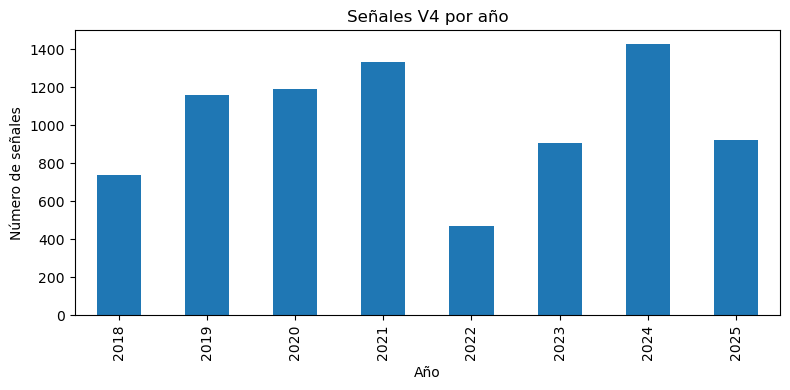

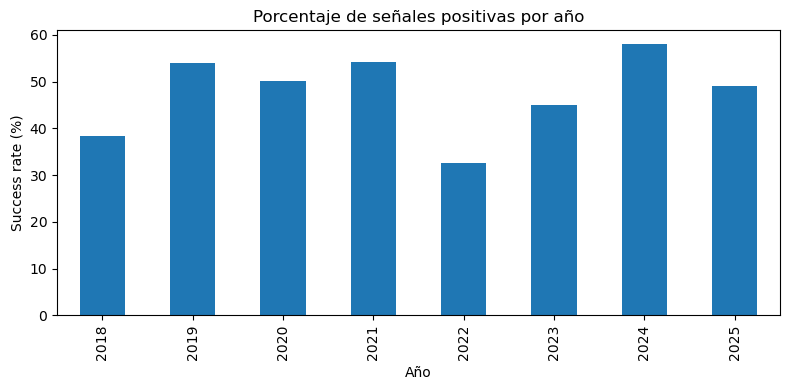

In [16]:
ax = summary_year.plot(x="signal_year", y="signals", kind="bar", legend=False, figsize=(8, 4))
ax.set_title("Señales V4 por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de señales")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_nb05_senales_por_anio.png", dpi=160)
plt.show()

ax = summary_year.plot(x="signal_year", y="success_rate_pct", kind="bar", legend=False, figsize=(8, 4))
ax.set_title("Porcentaje de señales positivas por año")
ax.set_xlabel("Año")
ax.set_ylabel("Success rate (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_nb05_success_rate_por_anio.png", dpi=160)
plt.show()


## 10. Splits temporales propuestos

El modelado posterior no se usa como train/test aleatorio, porque eso mezclaría información de distintos momentos y podría introducir leakage temporal. La validación es cronológica.


In [17]:
temporal_splits = pd.DataFrame([
    {"fold": 1, "train_years": "2018-2021", "validation_year": 2022, "test_year": 2023},
    {"fold": 2, "train_years": "2018-2022", "validation_year": 2023, "test_year": 2024},
    {"fold": 3, "train_years": "2018-2023", "validation_year": 2024, "test_year": 2025},
])

display(temporal_splits)


,fold,train_years,validation_year,test_year
0,1,2018-2021,2022,2023
1,2,2018-2022,2023,2024
2,3,2018-2023,2024,2025


## 11. Exportación de salidas

Este notebook exporta el dataset que utilizará el siguiente notebook de modelado supervisado.


In [18]:
OUT_CSV = OUTPUT_DIR / "dataset_supervisado_tecnico_v1.csv"
OUT_ZIP = OUTPUT_DIR / "dataset_supervisado_tecnico_v1.csv.zip"
DICT_CSV = OUTPUT_DIR / "feature_dictionary_tecnico_v1.csv"
SUMMARY_CSV = OUTPUT_DIR / "resumen_dataset_tecnico_v1.csv"
SPLITS_CSV = OUTPUT_DIR / "temporal_splits_tecnico_v1.csv"

df.to_csv(OUT_CSV, index=False)
with zipfile.ZipFile(OUT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(OUT_CSV, arcname=OUT_CSV.name)

feature_dictionary.to_csv(DICT_CSV, index=False)
summary_year.to_csv(SUMMARY_CSV, index=False)
temporal_splits.to_csv(SPLITS_CSV, index=False)

print("Exportado:")
print("-", OUT_ZIP)
print("-", DICT_CSV)
print("-", SUMMARY_CSV)
print("-", SPLITS_CSV)
print("-", FIG_DIR)


Exportado:
- /Users/rbr/TFM_MVP/JUNIO/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip
- /Users/rbr/TFM_MVP/JUNIO/outputs_nb05/feature_dictionary_tecnico_v1.csv
- /Users/rbr/TFM_MVP/JUNIO/outputs_nb05/resumen_dataset_tecnico_v1.csv
- /Users/rbr/TFM_MVP/JUNIO/outputs_nb05/temporal_splits_tecnico_v1.csv
- /Users/rbr/TFM_MVP/JUNIO/outputs_nb05/figures


## 12. Cierre metodológico

Con este notebook queda construido el dataset supervisado técnico v1. En el siguiente paso se entrenan  modelos supervisados sobre las columnas `feat_`, usando `target_combo_positive` como etiqueta principal y respetando particiones temporales.

El notebook siguiente debería comparar al menos:

- Dummy Classifier,
- Logistic Regression,
- Random Forest,
- XGBoost.

